# MetaCardis — Milestone 1
**Missing-modality-robust multi-omics distance estimation.**

The deliverable is an *n×n sample–sample distance matrix* from microbiome + metabolome that
survives an entire modality being missing. Ground truth is `standardize → PCA → Euclidean in
the first 2 PCs`, scored by a **Mantel test** — so the target geometry is **linear**.
This notebook reproduces the exploration and the mandatory naïve baseline.

In [1]:
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

RNG = np.random.default_rng(0)
sns.set_theme(style="whitegrid")
DATA = Path("..") / "data" / "train"
GROUP = "PATGROUPFINAL_C"

## Helpers — CLR, PCoA, PERMANOVA, Mantel (implemented from scratch)

In [2]:
def clr(frame, pseudo=1e-6):
    x = frame.to_numpy(float) + pseudo
    x = x / x.sum(1, keepdims=True)
    lx = np.log(x)
    return pd.DataFrame(lx - lx.mean(1, keepdims=True), index=frame.index, columns=frame.columns)

def pcoa(dist, k=2):
    n = dist.shape[0]; d2 = dist**2
    j = np.eye(n) - np.ones((n, n)) / n
    b = -0.5 * j @ d2 @ j
    vals, vecs = np.linalg.eigh(b); order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    coords = vecs[:, :k] * np.sqrt(np.maximum(vals[:k], 0))
    expl = np.maximum(vals, 0) / np.maximum(np.maximum(vals, 0).sum(), 1e-12)
    return coords, expl[:k]

def mantel(d1, d2, n_perm=199):
    iu = np.triu_indices_from(d1, k=1); v1, v2 = d1[iu], d2[iu]
    r = spearmanr(v1, v2).correlation; n = d1.shape[0]; c = 1
    for _ in range(n_perm):
        p = RNG.permutation(n)
        if abs(spearmanr(d1[np.ix_(p, p)][iu], v2).correlation) >= abs(r): c += 1
    return float(r), c / (n_perm + 1)

## 1. Load data and discover the real missing-modality structure
The tables are aligned by SampleID but the omics **values** are missing for ~40% of subjects.

In [3]:
micro = pd.read_csv(DATA / "microbiome.csv", index_col=0)
metab = pd.read_csv(DATA / "metabolome.csv", index_col=0)
meta  = pd.read_csv(DATA / "metadata.csv", index_col=0).loc[micro.index]
metab = metab.loc[micro.index]

has_micro = ~micro.isna().all(axis=1)
has_metab = ~metab.isna().all(axis=1)
complete  = has_micro & has_metab
print("complete both :", int(complete.sum()))
print("microbiome only:", int((has_micro & ~has_metab).sum()))
print("metabolome only:", int((~has_micro & has_metab).sum()))
print("\nmicrobiome row sums (should be ~1, i.e. relative abundance):",
      micro[has_micro].sum(axis=1).round(3).head(3).tolist())

complete both : 1042
microbiome only: 348
metabolome only: 348

microbiome row sums (should be ~1, i.e. relative abundance): [1.0, 1.0, 1.0]


**Finding.** 1042 both / 348 microbiome-only / 348 metabolome-only (disjoint). The whole-modality
missingness the project targets is *already in the data*. Microbiome is relative abundance
(compositional) → CLR; metabolome is heavy-tailed positive → log1p.

In [4]:
micro_clr = clr(micro[has_micro])
metab_log = np.log1p(metab[has_metab])

## 2. Disease distribution, demographics & missingness

In [5]:
print(meta[GROUP].value_counts().sort_index())
print("\nmetadata missing %:\n", meta.isna().mean().mul(100).round(1))
print("\nBMI missing by center:\n",
      meta.assign(m=meta["BMI_C"].isna()).groupby("CENTER_C")["m"].mean().round(2))

PATGROUPFINAL_C
1     230
2a    239
2b    128
3     528
4     107
5     149
6      90
7      18
8     249
Name: count, dtype: int64

metadata missing %:
 PATGROUPFINAL_C     0.0
GENDER             27.4
BMI_C              28.3
AGE                27.4
CENTER_C            0.0
dtype: float64

BMI missing by center:
 CENTER_C
Danemark    1.00
France      0.02
Germany     0.00
Name: m, dtype: float64


Class imbalance (T2D n=528 → CHF n=18) and **MNAR metadata**: Denmark = 100% missing
demographics (privacy law). Figures are in `../analysis/figures/` (regenerate via `analysis/eda.py`).

## 3. Microbiome geometry — PCoA, and CENTER vs disease (PERMANOVA)

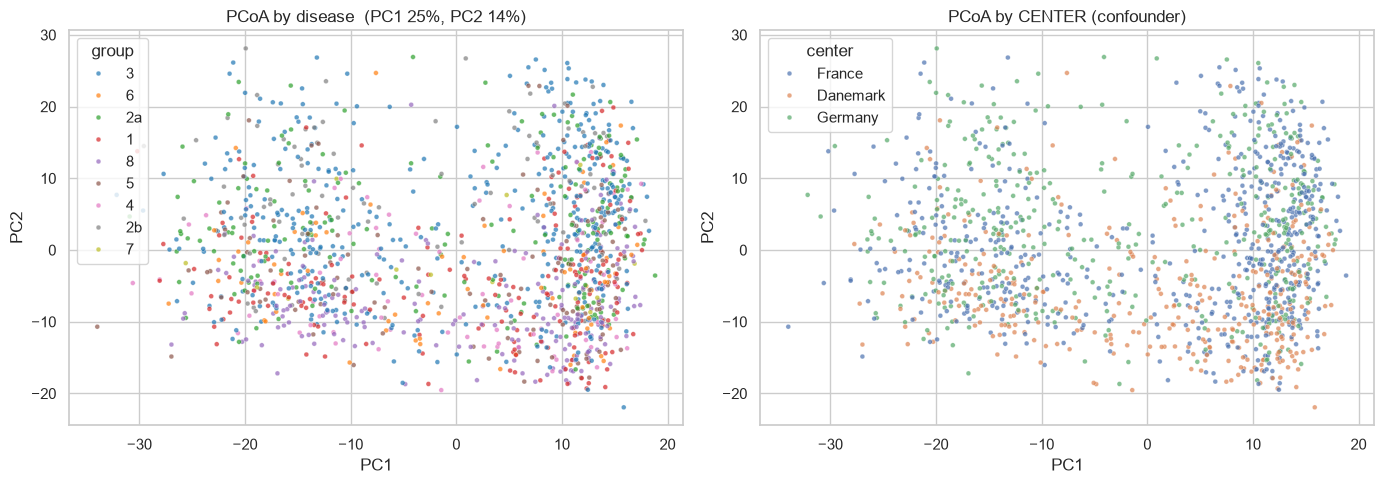

In [6]:
aitch = squareform(pdist(micro_clr.to_numpy()))
coords, expl = pcoa(aitch, 2)
pc = pd.DataFrame(coords, columns=["PC1","PC2"], index=micro_clr.index)
pc["group"]  = meta.loc[pc.index, GROUP].values
pc["center"] = meta.loc[pc.index, "CENTER_C"].values
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=pc, x="PC1", y="PC2", hue="group", s=12, palette="tab10", ax=ax[0], alpha=.7)
ax[0].set_title(f"PCoA by disease  (PC1 {expl[0]:.0%}, PC2 {expl[1]:.0%})")
sns.scatterplot(data=pc, x="PC1", y="PC2", hue="center", s=12, ax=ax[1], alpha=.7)
ax[1].set_title("PCoA by CENTER (confounder)"); plt.tight_layout(); plt.show()

PERMANOVA (full script `analysis/eda.py`) gives **CENTER F≈8.84 > disease-group F≈3.72** —
batch/geography is the dominant axis and a confounder baked into the grader's ground truth.

## 4. Cross-omics coupling is weak — this caps any imputation

In [7]:
cidx = micro_clr.index.intersection(metab_log.index)  # 1042 complete
mz = pd.DataFrame(StandardScaler().fit_transform(metab_log), index=metab_log.index, columns=metab_log.columns)
mv = micro_clr.loc[cidx, micro_clr.var().nlargest(30).index]
bv = mz.loc[cidx, mz.var().nlargest(30).index]
cc = np.array([[spearmanr(mv[a], bv[b]).correlation for b in bv.columns] for a in mv.columns])
print("max |Spearman| taxa<->metabolite:", round(float(np.nanmax(np.abs(cc))), 3))

max |Spearman| taxa<->metabolite: 0.382


Max |Spearman| ≈ **0.38** — only a metabolite-specific subset is predictable from microbiome.

## 5. Naïve baseline (mandatory): impute a dropped modality, then Mantel
Ground truth on the 1042 complete samples = standardize → PCA → Euclidean in 2 PCs.
Drop the metabolome for x% of samples, impute (mean / KNN / PLS), recompute distances, Mantel.

In [8]:
Xmi = pd.DataFrame(StandardScaler().fit_transform(micro_clr.loc[cidx]), index=cidx, columns=micro_clr.columns)
Xme = mz.loc[cidx]
gt = squareform(pdist(PCA(2, random_state=0).fit_transform(
    StandardScaler().fit_transform(np.hstack([Xmi.values, Xme.values])))))

n = len(cidx); rows = []
for frac in (0.1, 0.3, 0.5):
    miss = RNG.choice(n, int(frac*n), replace=False); obs = np.ones(n, bool); obs[miss] = False
    me_mean = Xme.values.copy(); me_mean[miss] = Xme.values[obs].mean(0)
    stk = Xme.values.copy(); stk[miss] = np.nan
    me_knn = KNNImputer(n_neighbors=10).fit_transform(np.hstack([Xmi.values, stk]))[:, Xmi.shape[1]:]
    pls = PLSRegression(n_components=15).fit(Xmi.values[obs], Xme.values[obs])
    me_pls = Xme.values.copy(); me_pls[miss] = pls.predict(Xmi.values[miss])
    row = {"drop%": int(frac*100)}
    for name, me in (("mean", me_mean), ("KNN", me_knn), ("PLS", me_pls)):
        pcs = PCA(2, random_state=0).fit_transform(StandardScaler().fit_transform(np.hstack([Xmi.values, me])))
        row[name] = round(mantel(gt, squareform(pdist(pcs)))[0], 3)
    rows.append(row)
pd.DataFrame(rows).set_index("drop%")

,mean,KNN,PLS
drop%,,,
10,0.948,0.948,0.947
30,0.874,0.867,0.868
50,0.791,0.794,0.772


**Key result:** mean imputation **ties/beats** KNN and PLS at every level. Because the target
is linear PCA of standardized features, a mean-imputed block ≈ 0 post-standardization and simply
stops contributing — the correct linear fallback — while weak cross-modal signal (r≤0.38) means
regression only adds noise. *The bar to beat at 50% missing is ≈0.77, already cleared trivially.*

## 6. Disease prediction with vs without the second modality

In [9]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
yc = meta.loc[cidx, GROUP].astype(str).values
both = cross_val_score(rf, np.hstack([Xmi.values, Xme.values]), yc, cv=cv, scoring="balanced_accuracy").mean()
mi_all = StandardScaler().fit_transform(micro_clr)
ym = meta.loc[micro_clr.index, GROUP].astype(str).values
only = cross_val_score(rf, mi_all, ym, cv=cv, scoring="balanced_accuracy").mean()
print(f"balanced acc  both omics={both:.3f}   microbiome-only={only:.3f}  (9-class, chance~0.11)")

balanced acc  both omics=0.260   microbiome-only=0.191  (9-class, chance~0.11)


## 7. Where we go next — the cutting-edge plan
Baseline ladder = mean / KNN / RF / **PLS→frozen-PCA**. The two inspiring 2025 methods we will
build and benchmark against it (concept reviewed in the slides):
1. **Augmented/Fused Gromov–Wasserstein OT** (SCOT+, 2025) — place a missing-modality sample by
   coupling within-modality geometries onto the joint-PCA anchor; AGW's feature term fixes GW's
   isometry ambiguity.
2. **miss-SNF** (Bioinformatics 2025) — fuse per-modality similarity networks; a missing source is
   reconstructed through shared neighbors; output is a fused n×n similarity → distance.

Evaluation: Mantel vs PCA-2PC ground truth, swept over missing-% (both directions), **subject-grouped
CV**, train-only scaler/PCA, performance + runtime vs the baseline.